# Decision Tree for Dengue Outbreak Prediction

This notebook implements a Decision Tree classifier to predict dengue outbreaks in Nepal using weather and environmental data. The model is trained, tuned, and evaluated using separate training, validation, and test datasets.

## 1. Import Required Libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Machine Learning
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Visualization
import matplotlib.pyplot as plt

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

## 2. Load the Dataset

### 2.1 Training Dataset

In [6]:
train_df = pd.read_csv("train.csv")
train_df.head()

,Year,dengue_total,Location,Month,monthly_avg_temperature,avg_daily_rain,avg_daily_humidity,avg_daily_soil_moisture,avg_daily_soil_temperature,avg_daily_snowfall,avg_daily_precipitation,daily_rain_density,average_humidity,avg_soil_moisture,avg_soil_temperature,avg_snowfall,avg_precipitation
0,2024,0,KALIKOT,May,10.223880,19.783870,88.951584,0.418761,10.755308,0.000000,19.783870,high,extreme,high,low,none,high
1,2022,0,PARSA,Feb,30.428612,6.673333,62.701965,0.234122,28.814114,0.000000,6.673333,moderate,high,moderate,high,none,moderate
2,2024,19,SALYAN,Sep,10.010685,0.100000,70.479485,0.319492,11.226091,0.000000,0.100000,low,high,high,low,none,low
3,2022,1,BAJHANG,Jan,-6.802581,0.000000,34.566444,0.366226,-1.123817,0.388387,0.551613,no,low,high,low,light,low
4,2022,0,KALIKOT,May,10.058961,13.132258,89.504610,0.415793,10.209129,0.000000,13.132258,high,extreme,high,low,none,high


### 2.2 Testing Dataset

In [7]:
test_df = pd.read_csv("test.csv")
test_df.head()

,Year,dengue_total,Location,Month,monthly_avg_temperature,avg_daily_rain,avg_daily_humidity,avg_daily_soil_moisture,avg_daily_soil_temperature,avg_daily_snowfall,avg_daily_precipitation,daily_rain_density,average_humidity,avg_soil_moisture,avg_soil_temperature,avg_snowfall,avg_precipitation
0,2023,0,DOLAKHA,Jul,22.582495,15.812903,85.182590,0.421109,22.287094,0.000000,15.812903,high,extreme,high,moderate,none,high
1,2024,55,ARGHAKHANCHI,Sep,10.086084,0.029032,65.987830,0.326807,10.154941,0.000000,0.029032,low,high,high,low,none,low
2,2024,4,UDAYAPUR,Jul,10.825872,0.512903,77.253334,0.258161,13.172967,0.000000,0.512903,low,high,moderate,low,none,low
3,2024,4,DOLAKHA,Aug,18.012869,3.325807,75.316990,0.390733,19.863623,0.000000,3.325807,moderate,high,high,moderate,none,moderate
4,2023,4,DARCHULA,Nov,5.665355,10.770968,91.192800,0.290584,-1.148665,0.045161,10.835484,high,extreme,moderate,low,light,high


### 2.3 Validation Dataset

In [8]:
val_df = pd.read_csv("val.csv")
val_df.head()

,Year,dengue_total,Location,Month,monthly_avg_temperature,avg_daily_rain,avg_daily_humidity,avg_daily_soil_moisture,avg_daily_soil_temperature,avg_daily_snowfall,avg_daily_precipitation,daily_rain_density,average_humidity,avg_soil_moisture,avg_soil_temperature,avg_snowfall,avg_precipitation
0,2023,2,SANKHUWASABHA,Dec,10.692419,2.193548,62.936783,0.239148,11.303670,0.0,2.193548,low,high,moderate,low,none,low
1,2023,0,SIRAHA,Dec,28.076279,8.280644,83.651380,0.388021,28.989265,0.0,8.280644,moderate,extreme,high,high,none,moderate
2,2023,1,SARLAHI,Feb,28.192223,10.076666,84.941230,0.381857,29.020670,0.0,10.076666,high,extreme,high,high,none,high
3,2024,3,RUPANDEHI,Jan,14.279301,1.061290,84.866560,0.317665,16.197376,0.0,1.061290,low,extreme,high,moderate,none,low
4,2023,0,TAPLEJUNG,Mar,11.096197,21.135487,90.306070,0.422427,9.387677,0.0,21.135487,high,extreme,high,low,none,high


## 3. Data Exploration
### 3.1 Training Dataset Exploration

In [14]:
# Display the first five rows of the training dataset
train_df.head()

,Year,dengue_total,Location,Month,monthly_avg_temperature,avg_daily_rain,avg_daily_humidity,avg_daily_soil_moisture,avg_daily_soil_temperature,avg_daily_snowfall,avg_daily_precipitation,daily_rain_density,average_humidity,avg_soil_moisture,avg_soil_temperature,avg_snowfall,avg_precipitation
0,2024,0,KALIKOT,May,10.223880,19.783870,88.951584,0.418761,10.755308,0.000000,19.783870,high,extreme,high,low,none,high
1,2022,0,PARSA,Feb,30.428612,6.673333,62.701965,0.234122,28.814114,0.000000,6.673333,moderate,high,moderate,high,none,moderate
2,2024,19,SALYAN,Sep,10.010685,0.100000,70.479485,0.319492,11.226091,0.000000,0.100000,low,high,high,low,none,low
3,2022,1,BAJHANG,Jan,-6.802581,0.000000,34.566444,0.366226,-1.123817,0.388387,0.551613,no,low,high,low,light,low
4,2022,0,KALIKOT,May,10.058961,13.132258,89.504610,0.415793,10.209129,0.000000,13.132258,high,extreme,high,low,none,high


In [15]:
# Display the dataset information
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62596 entries, 0 to 62595
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        62596 non-null  int64  
 1   dengue_total                62596 non-null  int64  
 2   Location                    62596 non-null  object 
 3   Month                       62596 non-null  object 
 4   monthly_avg_temperature     62596 non-null  float64
 5   avg_daily_rain              62596 non-null  float64
 6   avg_daily_humidity          62596 non-null  float64
 7   avg_daily_soil_moisture     62596 non-null  float64
 8   avg_daily_soil_temperature  62596 non-null  float64
 9   avg_daily_snowfall          62596 non-null  float64
 10  avg_daily_precipitation     62596 non-null  float64
 11  daily_rain_density          62596 non-null  object 
 12  average_humidity            62596 non-null  object 
 13  avg_soil_moisture           625

In [16]:
# Display the number of rows and columns
print("Training Dataset Shape:", train_df.shape)

Training Dataset Shape: (62596, 17)


In [17]:
# Display summary statistics for numerical features
train_df.describe()

,Year,dengue_total,monthly_avg_temperature,avg_daily_rain,avg_daily_humidity,avg_daily_soil_moisture,avg_daily_soil_temperature,avg_daily_snowfall,avg_daily_precipitation
count,62596.000000,62596.000000,62596.000000,62596.000000,62596.000000,62596.000000,62596.000000,62596.000000,62596.000000
mean,2023.001502,51.835581,15.797268,4.755448,71.380446,0.315917,16.354063,0.223860,5.074879
std,0.816847,359.301590,9.408848,6.042926,14.497634,0.078159,8.454122,1.019497,6.062751
min,2022.000000,0.000000,-16.712560,0.000000,10.414664,0.025777,-4.891570,0.000000,0.000000
25%,2022.000000,0.000000,10.387795,0.190323,62.092870,0.257529,10.819891,0.000000,0.382143
50%,2023.000000,2.000000,17.289791,1.885714,73.438300,0.323811,17.557453,0.000000,2.383871
75%,2024.000000,11.000000,22.695229,7.896666,83.261055,0.383340,22.564325,0.000000,8.300000
max,2024.000000,9891.000000,32.659233,35.351612,95.339400,0.504554,31.919470,18.687500,35.351612


In [18]:
# Check for duplicate rows
print("Number of duplicate rows:", train_df.duplicated().sum())

Number of duplicate rows: 0


In [19]:
# Check for missing values
train_df.isnull().sum()

,0
Year,0
dengue_total,0
Location,0
Month,0
monthly_avg_temperature,0
avg_daily_rain,0
avg_daily_humidity,0
avg_daily_soil_moisture,0
avg_daily_soil_temperature,0
avg_daily_snowfall,0


### 3.2 Testing Dataset Exploration

In [20]:
# Display the first five rows of the testing dataset
test_df.head()

,Year,dengue_total,Location,Month,monthly_avg_temperature,avg_daily_rain,avg_daily_humidity,avg_daily_soil_moisture,avg_daily_soil_temperature,avg_daily_snowfall,avg_daily_precipitation,daily_rain_density,average_humidity,avg_soil_moisture,avg_soil_temperature,avg_snowfall,avg_precipitation
0,2023,0,DOLAKHA,Jul,22.582495,15.812903,85.182590,0.421109,22.287094,0.000000,15.812903,high,extreme,high,moderate,none,high
1,2024,55,ARGHAKHANCHI,Sep,10.086084,0.029032,65.987830,0.326807,10.154941,0.000000,0.029032,low,high,high,low,none,low
2,2024,4,UDAYAPUR,Jul,10.825872,0.512903,77.253334,0.258161,13.172967,0.000000,0.512903,low,high,moderate,low,none,low
3,2024,4,DOLAKHA,Aug,18.012869,3.325807,75.316990,0.390733,19.863623,0.000000,3.325807,moderate,high,high,moderate,none,moderate
4,2023,4,DARCHULA,Nov,5.665355,10.770968,91.192800,0.290584,-1.148665,0.045161,10.835484,high,extreme,moderate,low,light,high


In [21]:
# Display the dataset information
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13415 entries, 0 to 13414
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        13415 non-null  int64  
 1   dengue_total                13415 non-null  int64  
 2   Location                    13415 non-null  object 
 3   Month                       13415 non-null  object 
 4   monthly_avg_temperature     13415 non-null  float64
 5   avg_daily_rain              13415 non-null  float64
 6   avg_daily_humidity          13415 non-null  float64
 7   avg_daily_soil_moisture     13415 non-null  float64
 8   avg_daily_soil_temperature  13415 non-null  float64
 9   avg_daily_snowfall          13415 non-null  float64
 10  avg_daily_precipitation     13415 non-null  float64
 11  daily_rain_density          13415 non-null  object 
 12  average_humidity            13415 non-null  object 
 13  avg_soil_moisture           134

In [22]:
# Display the number of rows and columns
print("Testing Dataset Shape:", test_df.shape)

Testing Dataset Shape: (13415, 17)


In [23]:
# Display summary statistics for numerical features
test_df.describe()

,Year,dengue_total,monthly_avg_temperature,avg_daily_rain,avg_daily_humidity,avg_daily_soil_moisture,avg_daily_soil_temperature,avg_daily_snowfall,avg_daily_precipitation
count,13415.000000,13415.000000,13415.000000,13415.000000,13415.000000,13415.000000,13415.000000,13415.000000,13415.000000
mean,2022.988669,54.371897,15.791107,4.811068,71.565883,0.315981,16.331886,0.220332,5.125485
std,0.815291,386.764369,9.391240,6.080364,14.316485,0.077102,8.453890,1.031878,6.108464
min,2022.000000,0.000000,-16.712560,0.000000,10.414664,0.025777,-4.891570,0.000000,0.000000
25%,2022.000000,0.000000,10.365591,0.210000,62.415985,0.257783,10.758421,0.000000,0.400000
50%,2023.000000,2.000000,17.196238,1.925806,73.661560,0.323811,17.467878,0.000000,2.419355
75%,2024.000000,11.000000,22.753817,8.025807,83.298970,0.383340,22.615030,0.000000,8.320001
max,2024.000000,9891.000000,32.659233,35.351612,95.339400,0.504554,31.919470,18.687500,35.351612


In [24]:
# Check for duplicate rows
print("Number of duplicate rows:", test_df.duplicated().sum())

Number of duplicate rows: 0


In [25]:
# Check for missing values
test_df.isnull().sum()

,0
Year,0
dengue_total,0
Location,0
Month,0
monthly_avg_temperature,0
avg_daily_rain,0
avg_daily_humidity,0
avg_daily_soil_moisture,0
avg_daily_soil_temperature,0
avg_daily_snowfall,0


### 3.3 Validation Dataset Exploration

In [26]:
# Display the first five rows of the validation dataset
val_df.head()

,Year,dengue_total,Location,Month,monthly_avg_temperature,avg_daily_rain,avg_daily_humidity,avg_daily_soil_moisture,avg_daily_soil_temperature,avg_daily_snowfall,avg_daily_precipitation,daily_rain_density,average_humidity,avg_soil_moisture,avg_soil_temperature,avg_snowfall,avg_precipitation
0,2023,2,SANKHUWASABHA,Dec,10.692419,2.193548,62.936783,0.239148,11.303670,0.0,2.193548,low,high,moderate,low,none,low
1,2023,0,SIRAHA,Dec,28.076279,8.280644,83.651380,0.388021,28.989265,0.0,8.280644,moderate,extreme,high,high,none,moderate
2,2023,1,SARLAHI,Feb,28.192223,10.076666,84.941230,0.381857,29.020670,0.0,10.076666,high,extreme,high,high,none,high
3,2024,3,RUPANDEHI,Jan,14.279301,1.061290,84.866560,0.317665,16.197376,0.0,1.061290,low,extreme,high,moderate,none,low
4,2023,0,TAPLEJUNG,Mar,11.096197,21.135487,90.306070,0.422427,9.387677,0.0,21.135487,high,extreme,high,low,none,high


In [27]:
# Display the dataset information
val_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13413 entries, 0 to 13412
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        13413 non-null  int64  
 1   dengue_total                13413 non-null  int64  
 2   Location                    13413 non-null  object 
 3   Month                       13413 non-null  object 
 4   monthly_avg_temperature     13413 non-null  float64
 5   avg_daily_rain              13413 non-null  float64
 6   avg_daily_humidity          13413 non-null  float64
 7   avg_daily_soil_moisture     13413 non-null  float64
 8   avg_daily_soil_temperature  13413 non-null  float64
 9   avg_daily_snowfall          13413 non-null  float64
 10  avg_daily_precipitation     13413 non-null  float64
 11  daily_rain_density          13413 non-null  object 
 12  average_humidity            13413 non-null  object 
 13  avg_soil_moisture           134

In [28]:
# Display the number of rows and columns
print("Validation Dataset Shape:", val_df.shape)

Validation Dataset Shape: (13413, 17)


In [29]:
# Display summary statistics for numerical features
val_df.describe()

,Year,dengue_total,monthly_avg_temperature,avg_daily_rain,avg_daily_humidity,avg_daily_soil_moisture,avg_daily_soil_temperature,avg_daily_snowfall,avg_daily_precipitation
count,13413.000000,13413.000000,13413.000000,13413.000000,13413.000000,13413.000000,13413.000000,13413.000000,13413.000000
mean,2023.004324,59.491016,15.927439,4.774062,71.371936,0.314546,16.440498,0.220210,5.088271
std,0.816059,413.737144,9.233372,6.039575,14.411881,0.078470,8.325481,1.041116,6.067074
min,2022.000000,0.000000,-16.712560,0.000000,10.414664,0.025777,-4.891570,0.000000,0.000000
25%,2022.000000,0.000000,10.594625,0.190323,62.132250,0.257044,10.905983,0.000000,0.380645
50%,2023.000000,2.000000,17.349680,1.938710,73.042670,0.322373,17.625147,0.000000,2.374194
75%,2024.000000,11.000000,22.723522,8.009999,83.288895,0.382280,22.654009,0.000000,8.319999
max,2024.000000,9891.000000,32.659233,35.351612,95.339400,0.504554,31.919470,18.687500,35.351612


In [30]:
# Check for duplicate rows
print("Number of duplicate rows:", val_df.duplicated().sum())

Number of duplicate rows: 0


In [31]:
# Check for missing values
val_df.isnull().sum()

,0
Year,0
dengue_total,0
Location,0
Month,0
monthly_avg_temperature,0
avg_daily_rain,0
avg_daily_humidity,0
avg_daily_soil_moisture,0
avg_daily_soil_temperature,0
avg_daily_snowfall,0


## 4. Feature Engineering
### 4.1 Create Binary Target Variable

In [32]:
# Convert dengue_total into a binary classification target

train_df["target"] = (train_df["dengue_total"] > 0).astype(int)
val_df["target"] = (val_df["dengue_total"] > 0).astype(int)
test_df["target"] = (test_df["dengue_total"] > 0).astype(int)

In [33]:
print(train_df["target"].value_counts())

target
1    39534
0    23062
Name: count, dtype: int64


### 4.2 Separate Features and Target

In [34]:
# Columns to remove
drop_columns = [
    "dengue_total",
    "target",
    "daily_rain_density",
    "average_humidity",
    "avg_soil_moisture",
    "avg_soil_temperature",
    "avg_snowfall",
    "avg_precipitation"
]

# Features
X_train = train_df.drop(columns=drop_columns)
X_val = val_df.drop(columns=drop_columns)
X_test = test_df.drop(columns=drop_columns)

# Target
y_train = train_df["target"]
y_val = val_df["target"]
y_test = test_df["target"]

In [35]:
print("Training Features :", X_train.shape)
print("Validation Features:", X_val.shape)
print("Testing Features :", X_test.shape)

Training Features : (62596, 10)
Validation Features: (13413, 10)
Testing Features : (13415, 10)


### 4.3 Encode Categorical Features
Decision Trees cannot work directly with text such as Location and Month, so we convert these categorical values into numerical features using One-Hot Encoding.

In [36]:
# Identify categorical columns
categorical_features = ["Location", "Month"]

In [37]:
# Apply One-Hot Encoding

X_train = pd.get_dummies(X_train, columns=categorical_features)

X_val = pd.get_dummies(X_val, columns=categorical_features)

X_test = pd.get_dummies(X_test, columns=categorical_features)

In [38]:
# Ensure all datasets have the same feature columns

X_train, X_val = X_train.align(X_val, join="left", axis=1, fill_value=0)

X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

In [39]:
# Display the final feature dimensions

print("Training Features :", X_train.shape)
print("Validation Features:", X_val.shape)
print("Testing Features :", X_test.shape)

Training Features : (62596, 89)
Validation Features: (13413, 89)
Testing Features : (13415, 89)


## 5. Decision Tree Model Development
### 5.1 Train the Baseline Decision Tree

In [41]:
# Import the Decision Tree classifier
from sklearn.tree import DecisionTreeClassifier

# Create the baseline Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


### 5.2 Make Predictions

In [42]:
# Predict on the validation dataset
y_val_pred = dt_model.predict(X_val)

# Predict class probabilities
y_val_prob = dt_model.predict_proba(X_val)[:, 1]

### 5.3 Evaluate the Baseline Model

In [43]:
# Calculate evaluation metrics

accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

Accuracy : 0.9908
Precision: 0.9927
Recall   : 0.9928
F1 Score : 0.9927
ROC AUC  : 0.9901


### 5.4 Classification Report

In [44]:
# Display the classification report
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4942
           1       0.99      0.99      0.99      8471

    accuracy                           0.99     13413
   macro avg       0.99      0.99      0.99     13413
weighted avg       0.99      0.99      0.99     13413



### 5.5 Confusion Matrix

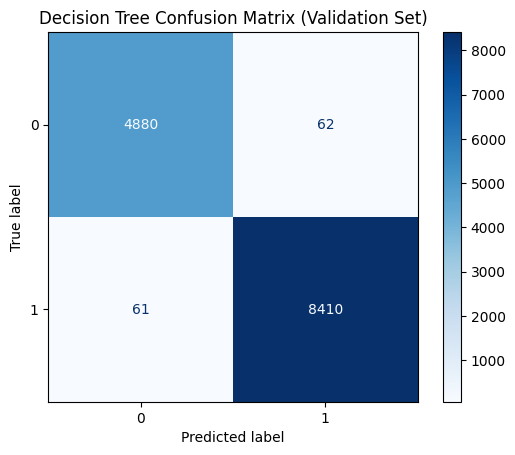

In [45]:
# Generate the confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")
plt.title("Decision Tree Confusion Matrix (Validation Set)")
plt.show()

### 5.6 ROC Curve

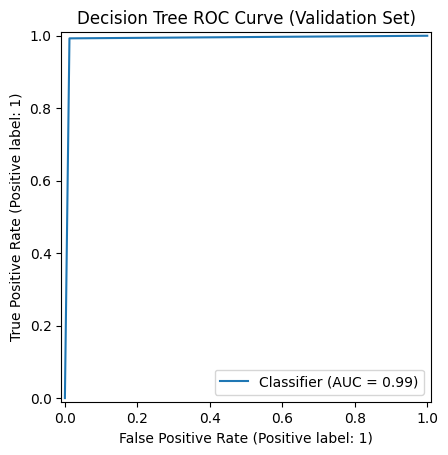

In [46]:
# Plot the ROC Curve
RocCurveDisplay.from_predictions(y_val, y_val_prob)

plt.title("Decision Tree ROC Curve (Validation Set)")
plt.show()

## 6. Hyperparameter Tuning
### 6.1 Define the Parameter Grid

In [52]:
# Define the parameter grid for tuning

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

### 6.2 Perform Grid Search

In [53]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

# Create the Grid Search object
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Train the models
grid_search.fit(X_train, y_train)

print("Grid Search completed successfully.")

Grid Search completed successfully.


### 6.3 Display the Best Parameters

In [54]:
# Display the best parameters
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


### 6.4 Display the Best Validation Score

In [55]:
# Display the best cross-validation accuracy
print("Best Cross-Validation Accuracy:")
print(grid_search.best_score_)

Best Cross-Validation Accuracy:
0.9876988727932264


### 6.5 Train the Optimized Decision Tree

In [56]:
# Train the optimized Decision Tree model

best_dt_model = grid_search.best_estimator_

best_dt_model.fit(X_train, y_train)

print("Optimized Decision Tree model trained successfully.")

Optimized Decision Tree model trained successfully.


### 6.6 Evaluate on the Test Dataset

In [57]:
# Make predictions on the test dataset

y_test_pred = best_dt_model.predict(X_test)
y_test_prob = best_dt_model.predict_proba(X_test)[:, 1]

In [58]:
# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
roc_auc = roc_auc_score(y_test, y_test_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

Accuracy : 0.9893
Precision: 0.9919
Recall   : 0.9913
F1 Score : 0.9916
ROC AUC  : 0.9886


In [59]:
# Display the classification report

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4936
           1       0.99      0.99      0.99      8479

    accuracy                           0.99     13415
   macro avg       0.99      0.99      0.99     13415
weighted avg       0.99      0.99      0.99     13415



### 6.7 Test Confusion Matrix

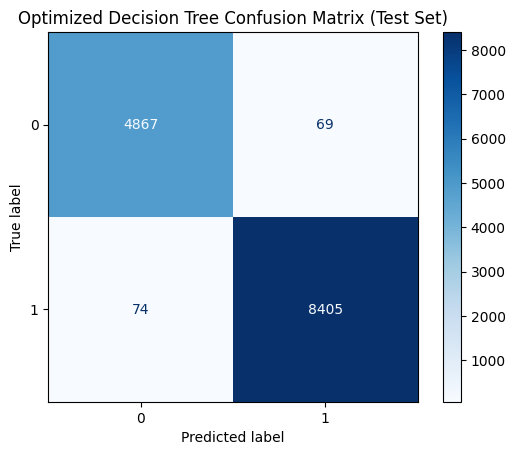

In [60]:
# Plot the confusion matrix

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Optimized Decision Tree Confusion Matrix (Test Set)")

plt.show()

## 7. Model Interpretation
### 7.1 Feature Importance

In [61]:
# Create a DataFrame of feature importances

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_dt_model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the top 10 most important features
feature_importance.head(10)

,Feature,Importance
0,Year,0.097582
88,Month_Sep,0.050222
87,Month_Oct,0.048791
78,Month_Aug,0.044238
86,Month_Nov,0.037170
85,Month_May,0.033835
82,Month_Jul,0.031134
79,Month_Dec,0.028035
77,Month_Apr,0.024207
5,avg_daily_soil_temperature,0.022141


### 7.2 Plot Feature Importance

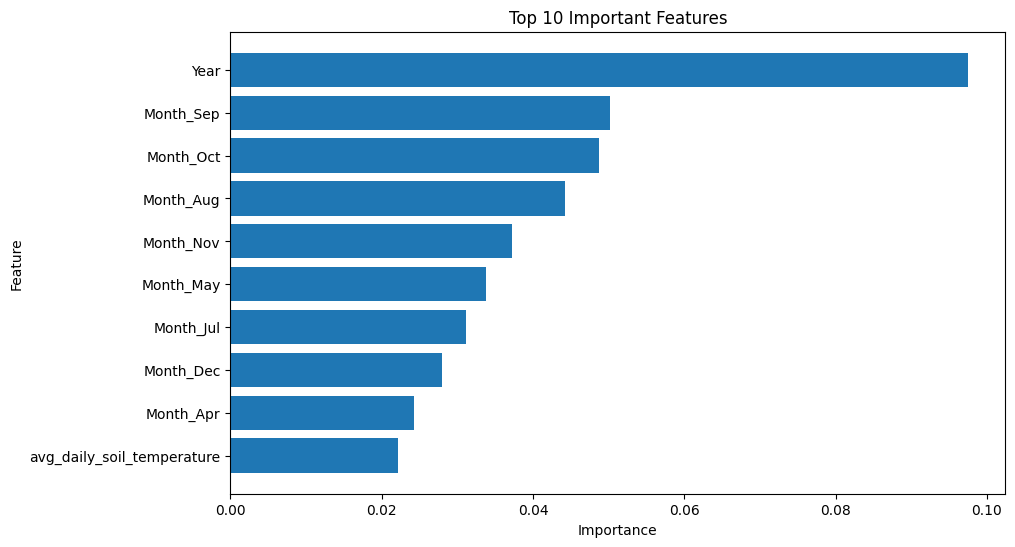

In [62]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

### 7.3 Visualize the Decision Tree

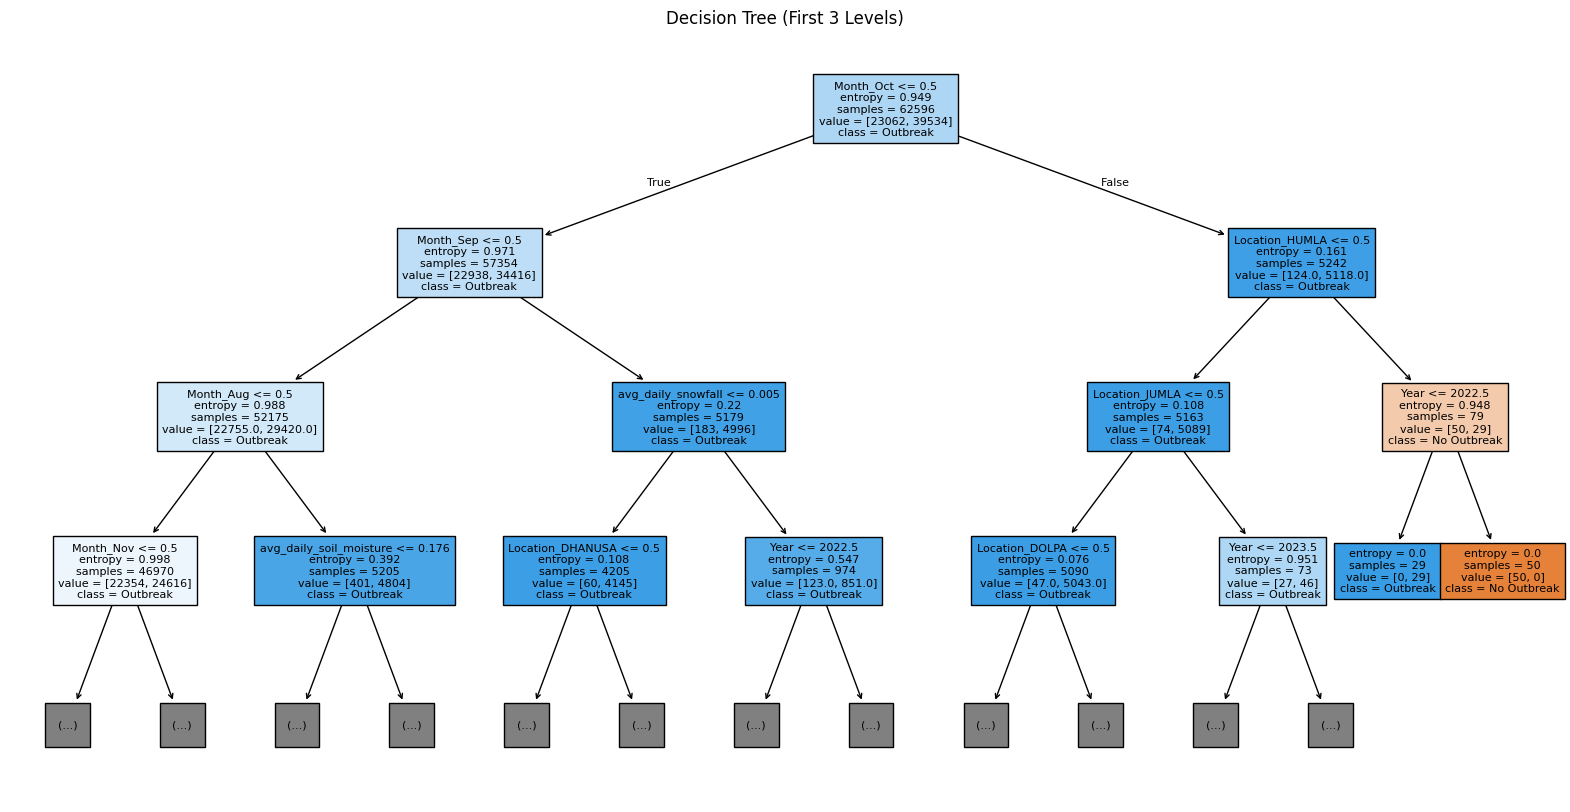

In [63]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    best_dt_model,
    max_depth=3,
    filled=True,
    feature_names=X_train.columns,
    class_names=["No Outbreak", "Outbreak"],
    fontsize=8
)

plt.title("Decision Tree (First 3 Levels)")

plt.show()